Libs

In [1]:
pip install "transformers<4.48.0"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoConfig,
    XLMRobertaPreTrainedModel,
    XLMRobertaModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    set_seed
)
from transformers.modeling_outputs import SequenceClassifierOutput

2026-03-07 14:29:34.888416: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772893774.910110     255 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772893774.916630     255 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772893774.933890     255 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772893774.933915     255 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772893774.933918     255 computation_placer.cc:177] computation placer alr

In [3]:
def set_up(seed=42):
  set_seed(seed)
  os.environ["PYTHONHASHSEED"] = str(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

In [4]:
SEED = 42
set_up(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


Preprocessing

In [5]:
TRAIN_DATASET_PATH = "/kaggle/input/datasets/haibuii2006/legalai/train.csv"
VAL_DATASET_PATH = "/kaggle/input/datasets/haibuii2006/legalai/val.csv"
TEST_DATASET_PATH = "/kaggle/input/datasets/haibuii2006/legalai/test.csv"
OUTPUT_PATH = "/kaggle/working/models/deberta_cross_encoder_no_expand"

In [6]:
df_train = pd.read_csv(TRAIN_DATASET_PATH)
df_val = pd.read_csv(VAL_DATASET_PATH)
df_test = pd.read_csv(TEST_DATASET_PATH)

In [7]:
TARGET_SAMPLES = 3000
MAX_SAMPLES_CLASS_0 = 4500
MAX_LEN = 192
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nice_class_map = {
    1: "Chemicals, Industry, Science, Photography",
    2: "Paints, Varnishes, Lacquers, Preservatives",
    3: "Cosmetics, Soaps, Perfumery, Cleaning preparations",
    4: "Industrial oils, Greases, Fuels, Candles",
    5: "Pharmaceuticals, Medical, Hygiene, Dietetic food",
    6: "Common metals, Hardware, Metal building materials",
    7: "Machines, Motors, Engines, Tools",
    8: "Hand tools, Cutlery, Side arms, Razors",
    9: "Electronics, Computers, Software, Scientific instruments, Mobile phones",
    10: "Medical devices, Surgical instruments, Orthopedic",
    11: "Lighting, Heating, Cooling, Cooking appliances",
    12: "Vehicles, Transport apparatus, Cars, Bikes",
    13: "Firearms, Ammunition, Explosives",
    14: "Jewelry, Watches, Precious metals, Gemstones",
    15: "Musical instruments",
    16: "Paper, Printed matter, Stationery, Office requisites",
    17: "Rubber, Plastics, Insulation materials",
    18: "Leather, Bags, Wallets, Umbrellas",
    19: "Building materials (Non-metallic), Asphalt, Cement",
    20: "Furniture, Mirrors, Picture frames",
    21: "Household utensils, Kitchenware, Glassware, Combs",
    22: "Ropes, Strings, Nets, Tents, Sacks",
    23: "Yarns, Threads for textile",
    24: "Textiles, Bed covers, Table covers, Fabrics",
    25: "Clothing, Footwear, Headgear, Fashion",
    26: "Lace, Embroidery, Ribbons, Buttons",
    27: "Carpets, Rugs, Mats, Floor coverings",
    28: "Games, Toys, Sports equipment",
    29: "Meat, Fish, Poultry, Processed fruits & vegetables",
    30: "Coffee, Tea, Bread, Rice, Sweets, Spices",
    31: "Agricultural products, Fresh fruits, Vegetables, Seeds",
    32: "Beers, Mineral waters, Non-alcoholic drinks",
    33: "Alcoholic beverages (except beer), Wines, Spirits",
    34: "Tobacco, Smokers' articles, Matches",

    35: "Advertising, Business management, Retail services, Marketing",
    36: "Insurance, Financial affairs, Real estate, Banking",
    37: "Building construction, Repair, Installation services",
    38: "Telecommunications, Broadcasting",
    39: "Transport, Packaging, Storage of goods, Travel",
    40: "Treatment of materials, Recycling, Manufacturing services",
    41: "Education, Training, Entertainment, Sporting activities",
    42: "Technology services, Software development, IT consulting",
    43: "Food and drink services, Restaurants, Hotels",
    44: "Medical services, Hygiene, Beauty care (Spa/Salon)",
    45: "Legal services, Security services, Social services"
}

In [8]:
def preprocess(df):
  label_mapping = {
    'Dissimilar': 0,
    'Low similar': 1,
    'Similar': 2,
    'High similar': 3,
    'Identical': 4
  }
  df['label_score'] = df['Similarity'].map(label_mapping)
  df = df.dropna(subset=['label_score'])
  df['label_score'] = df['label_score'].astype(int)

  df['input_text_1'] = df['Term 1']

  df['input_text_2'] = df['Term 2']
  return df

In [9]:
df_train = preprocess(df_train)
df_val = preprocess(df_val)
df_test = preprocess(df_test)

In [10]:
df_train['label_score'].value_counts().sort_index()

label_score
0    8259
1     565
2    1903
3     272
4    3940
Name: count, dtype: int64

In [11]:
df_train.head()

,Pair ID,Class 1,Term 1,Similarity,Class 2,Term 2,label_score,input_text_1,input_text_2
0,0015146-0007836,35,business administration,Dissimilar,41,entertainment services,0,business administration,entertainment services
1,0015146-0058633,35,business administration,Dissimilar,39,organisation of trips,0,business administration,organisation of trips
2,0046364-0067216,25,clothing,Identical,25,long johns,4,clothing,long johns
3,0073918-0047848,9,scientific and laboratory devices for treatmen...,Dissimilar,16,decoration and art materials and media,0,scientific and laboratory devices for treatmen...,decoration and art materials and media
4,0047026-0031233,30,tea,Low similar,30,tea essences,1,tea,tea essences


Data Balance

In [12]:
df_0 = df_train[df_train['label_score'] == 0]
df_1 = df_train[df_train['label_score'] == 1]
df_2 = df_train[df_train['label_score'] == 2]
df_3 = df_train[df_train['label_score'] == 3]
df_4 = df_train[df_train['label_score'] == 4]

In [13]:
def calculate_jaccard(text1, text2):
    set1 = set(str(text1).lower().split())
    set2 = set(str(text2).lower().split())
    if len(set1) == 0 or len(set2) == 0: return 0.0
    intersection = len(set1.intersection(set2))
    union = len(set1) + len(set2) - intersection
    return intersection / union

In [14]:
df_0['jaccard'] = df_0.apply(lambda x: calculate_jaccard(x['Term 1'], x['Term 2']), axis=1)

/tmp/ipykernel_255/2748097805.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_0['jaccard'] = df_0.apply(lambda x: calculate_jaccard(x['Term 1'], x['Term 2']), axis=1)


In [15]:
df_0.head()

,Pair ID,Class 1,Term 1,Similarity,Class 2,Term 2,label_score,input_text_1,input_text_2,jaccard
0,0015146-0007836,35,business administration,Dissimilar,41,entertainment services,0,business administration,entertainment services,0.000000
1,0015146-0058633,35,business administration,Dissimilar,39,organisation of trips,0,business administration,organisation of trips,0.000000
3,0073918-0047848,9,scientific and laboratory devices for treatmen...,Dissimilar,16,decoration and art materials and media,0,scientific and laboratory devices for treatmen...,decoration and art materials and media,0.083333
5,0016148-0033523,33,wine,Dissimilar,33,cream liqueurs,0,wine,cream liqueurs,0.000000
6,0009379-0019852,21,make-up removing appliances,Dissimilar,9,sound reproduction apparatus,0,make-up removing appliances,sound reproduction apparatus,0.000000


In [16]:
hard_negatives = df_0[df_0['jaccard'] > 0]
easy_negatives = df_0[df_0['jaccard'] == 0]
print(len(hard_negatives))
print(len(easy_negatives))
n_easy_keep = max(0, MAX_SAMPLES_CLASS_0 - len(hard_negatives))
if len(easy_negatives) > n_easy_keep:
    easy_negatives_sampled = resample(easy_negatives, replace=False, n_samples=n_easy_keep, random_state=42)
else:
    easy_negatives_sampled = easy_negatives

1395
6864


In [17]:
df_0_final = pd.concat([hard_negatives, easy_negatives_sampled])
df_0_final = resample(df_0_final, replace=False, n_samples=MAX_SAMPLES_CLASS_0, random_state=42)

In [18]:
df_train.head()

,Pair ID,Class 1,Term 1,Similarity,Class 2,Term 2,label_score,input_text_1,input_text_2
0,0015146-0007836,35,business administration,Dissimilar,41,entertainment services,0,business administration,entertainment services
1,0015146-0058633,35,business administration,Dissimilar,39,organisation of trips,0,business administration,organisation of trips
2,0046364-0067216,25,clothing,Identical,25,long johns,4,clothing,long johns
3,0073918-0047848,9,scientific and laboratory devices for treatmen...,Dissimilar,16,decoration and art materials and media,0,scientific and laboratory devices for treatmen...,decoration and art materials and media
4,0047026-0031233,30,tea,Low similar,30,tea essences,1,tea,tea essences


In [19]:
def augment_and_balance(df_sub, target_count):
    # Đảo chiều (Symmetry) - A vs B thành B vs A
    df_flipped = df_sub.copy()
    df_flipped['input_text_1'] = df_sub['input_text_2']
    df_flipped['input_text_2'] = df_sub['input_text_1']

    df_aug = pd.concat([df_sub, df_flipped])

    current_count = len(df_aug)
    if current_count < target_count:
        df_final = resample(df_aug, replace=True, n_samples=target_count, random_state=42)
    elif current_count > target_count:
        df_final = resample(df_aug, replace=False, n_samples=target_count, random_state=42)
    else:
        df_final = df_aug

    return df_final

In [20]:
def augment_cross_pairing(df_input, target_labels=[3, 4]):
      # A , B high similar/ identical, B , C : high similar/ identical => A/C : high similar/identical
      df = df_input.copy()
      df['key_1'] = df['Class 1'].astype(str) + " | " + df['Term 1'].astype(str)
      df['key_2'] = df['Class 2'].astype(str) + " | " + df['Term 1'].astype(str)
      high_quality_df = df[df['label_score'].isin(target_labels)].copy()

      forward = high_quality_df[['key_1', 'key_2', 'label_score', 'Class 2', 'Term 2']].rename(
          columns={'key_1': 'parent', 'key_2': 'child', 'label_score': 'score', 'Class 2': 'class_child', 'Term 2': 'term_child'}
        )
      backward = high_quality_df[['key_2', 'key_1', 'label_score', 'Class 1', 'Term 1']].rename(
          columns={'key_2': 'parent', 'key_1': 'child', 'label_score': 'score', 'Class 1': 'class_child', 'Term 1': 'term_child'}
        )
      connections = pd.concat([forward, backward])

      merged = pd.merge(connections, connections, on='parent', suffixes=('_1', '_2'))
      new_pairs = merged[merged['child_1'] < merged['child_2']].copy()
      if len(new_pairs) == 0:
        return df_input
      new_pairs['label_score'] = new_pairs[['score_1', 'score_2']].min(axis=1)

      df_aug = pd.DataFrame({
            "Class 1": new_pairs["class_child_1"],
            "Term 1": new_pairs["term_child_1"],
            "Class 2": new_pairs['class_child_2'],
            "Term 2": new_pairs['term_child_2'],
            "label_score": new_pairs["label_score"],
            "input_text_1": new_pairs['class_child_1'].astype(str) + ": " + new_pairs['term_child_1'].astype(str),
            "input_text_2": new_pairs['class_child_2'].astype(str) + ": " + new_pairs['term_child_2'].astype(str)
        })

      existing_pairs = set(df['key_1'] + "_" + df['key_2']) | set(df['key_2'] + "_" + df['key_1'])
      df_aug['pair_id'] = df_aug['Class 1'].astype(str) + " | " + df_aug['Term 1'].astype(str) + "_" + \
                          df_aug['Class 2'].astype(str) + " | " + df_aug['Term 2'].astype(str)
      df_aug = df_aug[~df_aug['pair_id'].isin(existing_pairs)]
      df_aug = df_aug.drop(columns=['pair_id'])
      print(f"Number of cross_pairing: {len(df_aug)}")
      return pd.concat([df_input, df_aug], ignore_index=True)

Number of cross_pairing: 586

KẾT QUẢ EDA DỮ LIỆU CROSS-PAIRING
1. SỐ LƯỢNG:
- Gốc: 14939 cặp
- Mới: 586 cặp
- Tăng trưởng: +3.92%


/tmp/ipykernel_255/1824377060.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label_score', data=df_new_only, palette='viridis')


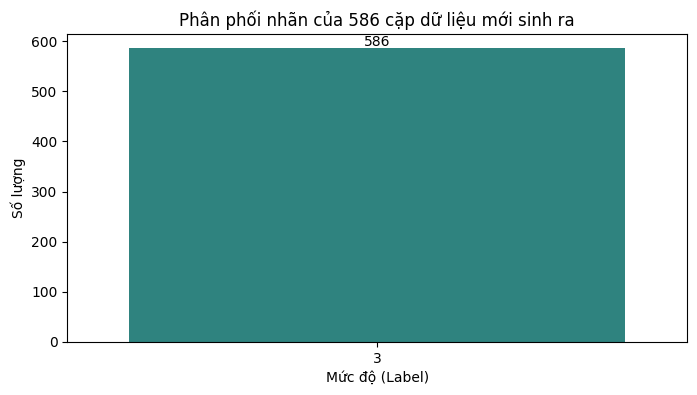

--------------------------------------------------------------------------------
Mức 3 | [24] towels of textile  <--->  [25] clothing
Mức 3 | [24] towels of textile  <--->  [25] ladies' clothing
Mức 3 | [24] towels of textile  <--->  [25] clothing
Mức 3 | [24] towels of textile  <--->  [25] clothing
Mức 3 | [24] towels of textile  <--->  [25] sports bras
Mức 3 | [24] towels of textile  <--->  [25] gloves including those made of skin, hide or fur
Mức 3 | [24] towels of textile  <--->  [25] clothing
Mức 3 | [24] towels of textile  <--->  [25] sweat bands for the wrist
Mức 3 | [24] towels of textile  <--->  [25] clothing
Mức 3 | [24] towels of textile  <--->  [25] athletic uniforms
--------------------------------------------------------------------------------
- Số cặp bị trùng lặp trong phần mới: 289


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_aug_full = augment_cross_pairing(df_train)

num_original = len(df_train)
num_total = len(df_aug_full)
num_new = num_total - num_original

if num_new == 0:
    print("Không sinh ra được cặp nào mới! (Có thể do dữ liệu gốc ít cặp Mức 3/4 quá)")
else:
    df_new_only = df_aug_full.iloc[num_original:].copy()

    print(f"\n{'='*40}")
    print(f"KẾT QUẢ EDA DỮ LIỆU CROSS-PAIRING")
    print(f"{'='*40}")
    print(f"1. SỐ LƯỢNG:")
    print(f"- Gốc: {num_original} cặp")
    print(f"- Mới: {num_new} cặp")
    print(f"- Tăng trưởng: +{num_new/num_original*100:.2f}%")

    plt.figure(figsize=(8, 4))
    ax = sns.countplot(x='label_score', data=df_new_only, palette='viridis')
    plt.title(f'Phân phối nhãn của {num_new} cặp dữ liệu mới sinh ra')
    plt.xlabel('Mức độ (Label)')
    plt.ylabel('Số lượng')
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    plt.show()

    print("-" * 80)
    sample_new = df_new_only.sample(min(10, len(df_new_only)), random_state=42)

    for idx, row in sample_new.iterrows():
        print(f"Mức {row['label_score']} | [{row['Class 1']}] {row['Term 1']}  <--->  [{row['Class 2']}] {row['Term 2']}")

    print("-" * 80)

    duplicates = df_new_only.duplicated(subset=['input_text_1', 'input_text_2']).sum()
    print(f"- Số cặp bị trùng lặp trong phần mới: {duplicates}")

In [22]:

df_1_final = augment_and_balance(df_train[df_train['label_score'] == 1], TARGET_SAMPLES)
df_3_final = augment_and_balance(df_train[df_train['label_score'] == 3], TARGET_SAMPLES)
df_2_sub = df_train[df_train['label_score'] == 2]
df_2_final = resample(df_2_sub, replace=(len(df_2_sub) < TARGET_SAMPLES), n_samples=TARGET_SAMPLES, random_state=42)

df_4_sub = df_train[df_train['label_score'] == 4]
df_4_final = resample(df_4_sub, replace=False, n_samples=TARGET_SAMPLES, random_state=42)

df_train_balanced = pd.concat([df_0_final, df_1_final, df_2_final, df_3_final, df_4_final])
df_train_balanced = df_train_balanced.sample(frac=1, random_state=42).reset_index(drop=True) # Shuffle

In [23]:
print(df_train_balanced['label_score'].value_counts().sort_index())

label_score
0    4500
1    3000
2    3000
3    3000
4    3000
Name: count, dtype: int64


Run Model

In [24]:
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from sklearn.utils import resample, class_weight
from sentence_transformers import CrossEncoder, InputExample, losses
from torch.utils.data import DataLoader
from sentence_transformers.cross_encoder.evaluation import CESoftmaxAccuracyEvaluator
from transformers import AutoTokenizer

In [25]:
train_samples = []
for i, row in df_train_balanced.iterrows():
    
    train_samples.append(InputExample(
        texts=[str(row['input_text_1']), str(row['input_text_2'])],
        label= int(row['label_score'])
    ))

train_dataloader = DataLoader(train_samples, shuffle=True, batch_size=32)

In [26]:
val_samples = []
for i, row in df_val.iterrows():
    val_samples.append(InputExample(
        texts=[str(row['input_text_1']), str(row['input_text_2'])],
        label= int(row['label_score'])
    ))

evaluator = CESoftmaxAccuracyEvaluator.from_input_examples(
    val_samples,
    name='Val_Check'
)

In [27]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_train_balanced['label_score']),
    y=df_train_balanced['label_score']
)
print("Class weights bị phạt: ", class_weights)

Class weights bị phạt:  [0.73333333 1.1        1.1        1.1        1.1       ]


In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

In [29]:
NUM_CLASSES = 5
model_name = 'microsoft/deberta-v3-base'
model = CrossEncoder(
    model_name,
    num_labels=NUM_CLASSES,
    max_length=256,
    automodel_args={"ignore_mismatched_sizes": True}
)
tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')
model.model.resize_token_embeddings(len(tokenizer))

The CrossEncoder `automodel_args` argument was renamed and is now deprecated, please use `model_kwargs` instead.
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Embedding(128001, 768, padding_idx=0)

In [30]:
model.loss_fct = nn.CrossEntropyLoss(weight=weights_tensor)

In [31]:
model.fit(
    train_dataloader=train_dataloader,
    evaluator=evaluator,
    save_best_model=True,
    optimizer_params={'lr': 2e-5},
    weight_decay=0.01,
    epochs=5,
    warmup_steps=int(len(train_dataloader) * 0.1),
    output_path='./output/nice_model_3prongs_strategy',
    show_progress_bar=True,
    evaluation_steps=500
)

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: dungcbh777 (dungcbh777-hanoi-university-of-science-and-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss,Val Check F1 Macro,Val Check F1 Micro,Val Check F1 Weighted
500,1.148700,No log,0.631341,0.801405,0.820108
1000,0.516800,No log,0.663017,0.785948,0.819676
1500,0.285700,No log,0.746032,0.865105,0.872460
2000,0.189300,No log,0.737761,0.859016,0.867525
2500,0.135300,No log,0.732381,0.863700,0.871576


Inference & Analysis

In [46]:
test_inputs = [
    [str(row['Term 1']), str(row['Term 2'])]
    for i, row in df_test.iterrows()
]
test_output = model.predict(test_inputs)
test_preds = np.argmax(test_output, axis=1)
test_true = df_test["label_score"].values

In [47]:
import numpy as np
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns
def safe_div(a, b):
    return float(a) / float(b) if b else 0.0

def main(df):
    y_true = df["label"].to_numpy()
    y_pred = df["pred"].to_numpy()

    labels = list(range(5))
    label_names = ['Dissimilar (0)', 'Low (1)', 'Similar (2)', 'High (3)', 'Identical (4)']
    K = len(labels)
    idx = {c: i for i, c in enumerate(labels)}

    cm = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        if t in idx and p in idx:
            cm[idx[t], idx[p]] += 1

    TP = np.diag(cm)
    FP = cm.sum(axis=0) - TP
    FN = cm.sum(axis=1) - TP
    TN = cm.sum() - (TP + FP + FN)

    per_class = []
    for i, c in enumerate(labels):
        support = cm[i, :].sum()
        precision = safe_div(TP[i], TP[i] + FP[i])
        recall = safe_div(TP[i], TP[i] + FN[i])
        f1 = safe_div(2 * precision * recall, precision + recall)
        acc = safe_div(TP[i] + TN[i], TP[i] + TN[i] + FP[i] + FN[i])
        per_class.append({
            "class": c,
            "support": int(support),
            "accuracy": acc,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    TP_micro = TP.sum()
    FP_micro = FP.sum()
    FN_micro = FN.sum()

    micro_precision = safe_div(TP_micro, TP_micro + FP_micro)
    micro_recall = safe_div(TP_micro, TP_micro + FN_micro)
    micro_f1 = safe_div(2 * micro_precision * micro_recall, micro_precision + micro_recall)

    macro_precision = np.mean([r["precision"] for r in per_class])
    macro_recall = np.mean([r["recall"] for r in per_class])
    macro_f1 = np.mean([r["f1"] for r in per_class])

    overall_acc = safe_div((y_true == y_pred).sum(), len(y_true))

    mae = np.mean(np.abs(y_true - y_pred))

    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')

    print("Per-class metrics (class | support | accuracy | precision | recall | f1):")
    for r in per_class:
        print(f"{r['class']:>2} | {r['support']:>6} | {r['accuracy']:.4f} | {r['precision']:.4f} | {r['recall']:.4f} | {r['f1']:.4f}")

    print("\nOverall accuracy:", f"{overall_acc:.4f}")
    print("Micro Precision | Recall | F1:", f"{micro_precision:.4f}", f"{micro_recall:.4f}", f"{micro_f1:.4f}")
    print("Macro Precision | Recall | F1:", f"{macro_precision:.4f}", f"{macro_recall:.4f}", f"{macro_f1:.4f}")

    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Quadratic Weighted Kappa (QWK): {qwk:.4f}")

    print("\nConfusion Matrix:")
    header = "    " + "".join([f" P{c:>3}" for c in labels])
    print(header)
    print("   " + "-" * len(header))
    for i, row in enumerate(cm):
        print(f"T{labels[i]} |" + "".join([f"{val:>4}" for val in row]))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names)

    plt.savefig('confusion_matrix.pdf', format='pdf', bbox_inches='tight')
    plt.savefig('confusion_matrix.png', format='png', dpi=300, bbox_inches='tight')
    plt.show()
    return overall_acc, mae, qwk

In [48]:
result_df = pd.DataFrame({
    "label": test_true,
    "pred": test_preds,
})

Per-class metrics (class | support | accuracy | precision | recall | f1):
 0 |   2360 | 0.9217 | 0.9720 | 0.8839 | 0.9259
 1 |    161 | 0.9566 | 0.4516 | 0.6957 | 0.5477
 2 |    543 | 0.9147 | 0.6405 | 0.7514 | 0.6915
 3 |     77 | 0.9791 | 0.4492 | 0.6883 | 0.5436
 4 |   1125 | 0.9494 | 0.9069 | 0.9004 | 0.9037

Overall accuracy: 0.8608
Micro Precision | Recall | F1: 0.8608 0.8608 0.8608
Macro Precision | Recall | F1: 0.6840 0.7839 0.7225
Mean Absolute Error (MAE): 0.2607
Quadratic Weighted Kappa (QWK): 0.8992

Confusion Matrix:
     P  0 P  1 P  2 P  3 P  4
   -----------------------------
T0 |2086  84 145  12  33
T1 |  16 112  20   3  10
T2 |  29  26 408  24  56
T3 |   2   3  14  53   5
T4 |  13  23  50  261013


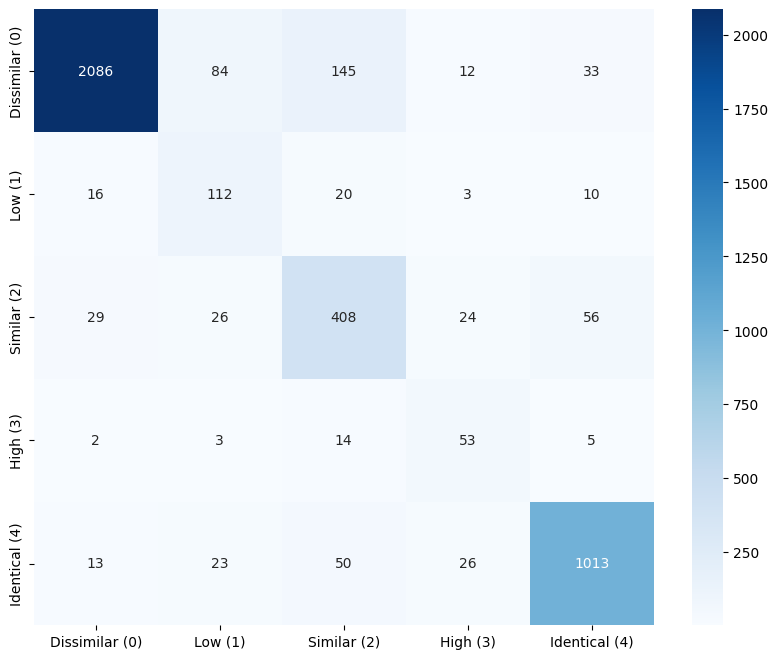

(0.8607594936708861,
 np.float64(0.2606657290201594),
 np.float64(0.8991837987513486))

In [49]:
main(result_df)

Save

In [50]:
import shutil
from google.colab import files

folder_to_zip = './output/nice_model_3prongs_strategy'

output_filename = 'my_trained_model'
shutil.make_archive(output_filename, 'zip', folder_to_zip)
files.download(output_filename + '.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>